In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hotels = pd.read_excel("./HotelCustomersDataset.xlsx")
hotels.head()

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
hotels.info()

<class 'pandas.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    83590 non-null  int64  
 1   Nationality           83590 non-null  str    
 2   Age                   79811 non-null  float64
 3   DaysSinceCreation     83590 non-null  int64  
 4   AverageLeadTime       83590 non-null  int64  
 5   LodgingRevenue        83590 non-null  float64
 6   OtherRevenue          83590 non-null  float64
 7   BookingsCanceled      83590 non-null  int64  
 8   BookingsNoShowed      83590 non-null  int64  
 9   BookingsCheckedIn     83590 non-null  int64  
 10  PersonsNights         83590 non-null  int64  
 11  RoomNights            83590 non-null  int64  
 12  DaysSinceLastStay     83590 non-null  int64  
 13  DaysSinceFirstStay    83590 non-null  int64  
 14  DistributionChannel   83590 non-null  str    
 15  MarketSegment         83590 no

# Assignment 1: Bar Chart and Histogram

* Build a histogram of lodging revenue with Seaborn. Filter your data to rows where LodgingRevenue is less than 1500. 
* Then, build a horizontal bar chart plotting the average room nights stayed for our top 5 countries by revenue ("DEU", "FRA", "PRT", "GBR", "ESP"). Change the color palette.

<Axes: xlabel='LodgingRevenue', ylabel='Percent'>

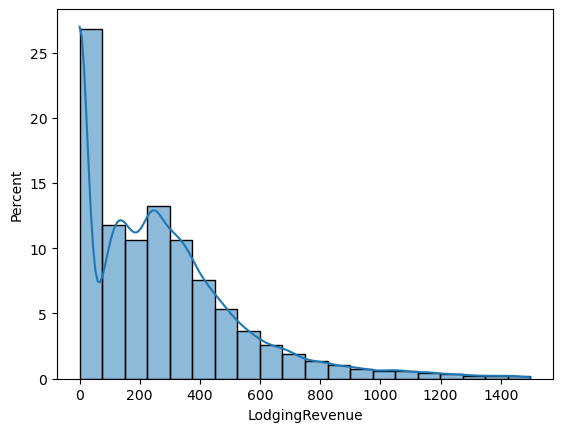

In [4]:
sns.histplot(
	x="LodgingRevenue",
	data=hotels.query("LodgingRevenue < 1500"),
	kde=True,
	stat="percent",
	bins=20,
)

In [5]:
top5_countries = (hotels
	.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR']")
	.groupby("Nationality")[["RoomNights", "LodgingRevenue"]]
	.mean()
	.sort_values(by="RoomNights", ascending=False))
top5_countries

,RoomNights,LodgingRevenue
Nationality,,
DEU,2.573690,304.278983
FRA,2.497021,306.658798
GBR,2.405499,311.127959
ESP,2.218890,301.083095
PRT,2.098301,234.113022


<Axes: xlabel='RoomNights', ylabel='Nationality'>

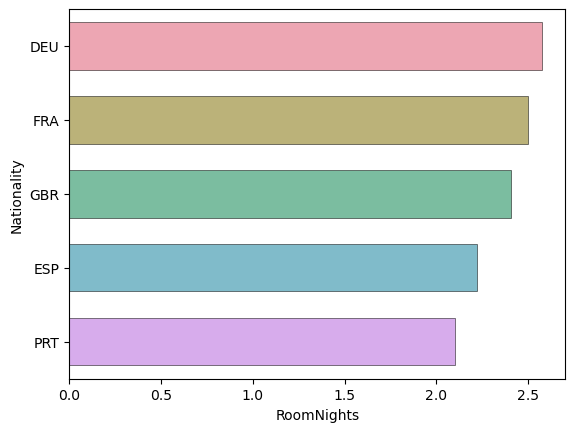

In [6]:
sns.barplot(
	x="RoomNights",
	y="Nationality",
	data=top5_countries,
	hue="Nationality",
	palette="husl",
	gap=0.2,
	ec="0.0",
	lw=0.5,
	alpha=0.7
)

# Assignment 2: Box and Violin Plots

* Build a single boxplot of LodgingRevenue for our top 5 countries, where nightly revenue is less than 1500.
* Then, build a chart that has one violinplot for each country. Look at these plots both without a filter and with lodging revenue filtered to less than 1500.
* Finally, build a violinplot for the Age distribution for each of our top 5 countries.

<Axes: ylabel='LodgingRevenue'>

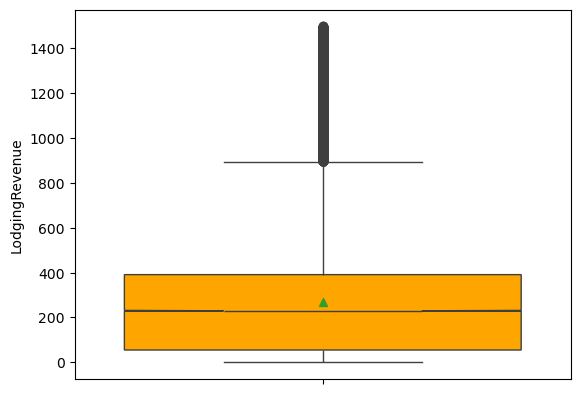

In [7]:
sns.boxplot(
	y="LodgingRevenue",
	data=hotels.query("LodgingRevenue < 1500"),

	notch=True,
	patch_artist=True,
	boxprops={"facecolor":"orange"},

	showmeans=True,
	meanline=False,

	whis=1.5,
)

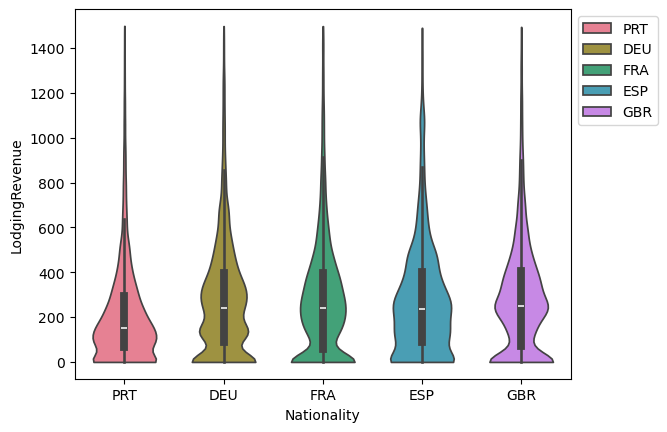

In [8]:
sns.violinplot(
	x="Nationality",
	y="LodgingRevenue",
	data=hotels.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR'] and LodgingRevenue < 1500 "),
	hue="Nationality",
	palette="husl",
	legend="brief",
	
	gap=0.2,
	cut=0,
	
	bw_adjust=1,
	density_norm="width",
	alpha=1
)
plt.legend(bbox_to_anchor=(1, 1));

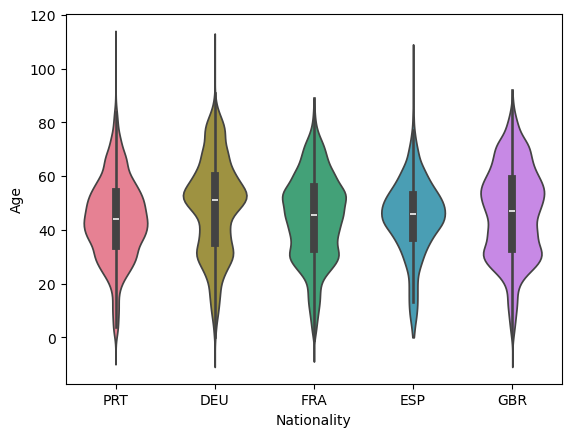

In [9]:
sns.violinplot(
	x="Nationality",
	y="Age",
	data=hotels.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR'] and LodgingRevenue < 1500 "),
	hue="Nationality",
	palette="husl",
	gap=0.2,
	cut=0,
	
	bw_adjust=1,
	density_norm="count",
	alpha=1
);

# Assigment 3: Linear Relationship Plots

* Build a plot with a regression line comparing LodgingRevenue as y and RoomNights as x for rows in our top 5 countries.
* Then, build the same chart in bullet 1 but with a separate line for each of our top 5 countries. Which country appears to pay the most per night?
* Finally, build a pairplot with the columns: Age, LodgingRevenue, OtherRevenue, PersonsNights, RoomNights, and DaysSinceLastStay

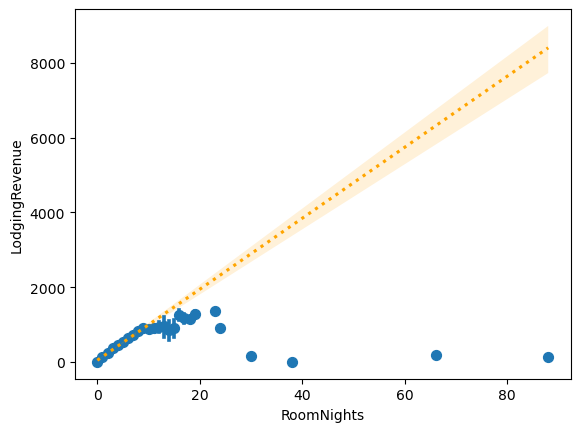

In [10]:
sns.regplot(
	x="RoomNights",
	y="LodgingRevenue",
	data=hotels.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR'] and LodgingRevenue < 1500"),
	order=1,
	truncate=True,
	y_jitter=True,
	x_estimator=np.mean,
	ci=90,
	line_kws={"color":"orange", "ls":":"}
);

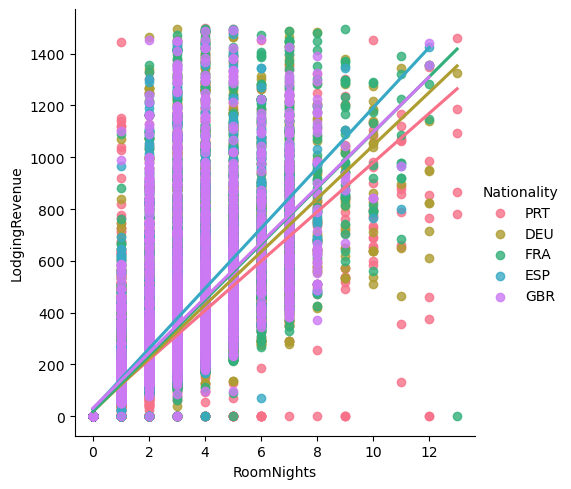

In [11]:
sns.lmplot(
	x="RoomNights",
	y="LodgingRevenue",
	data=hotels.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR'] and LodgingRevenue < 1500 and RoomNights < 14"),
	hue="Nationality",
	palette="husl",
	legend="brief",
	order=1,
	truncate=True,
	y_jitter=True,
	# x_estimator=np.mean,
	ci=None
)

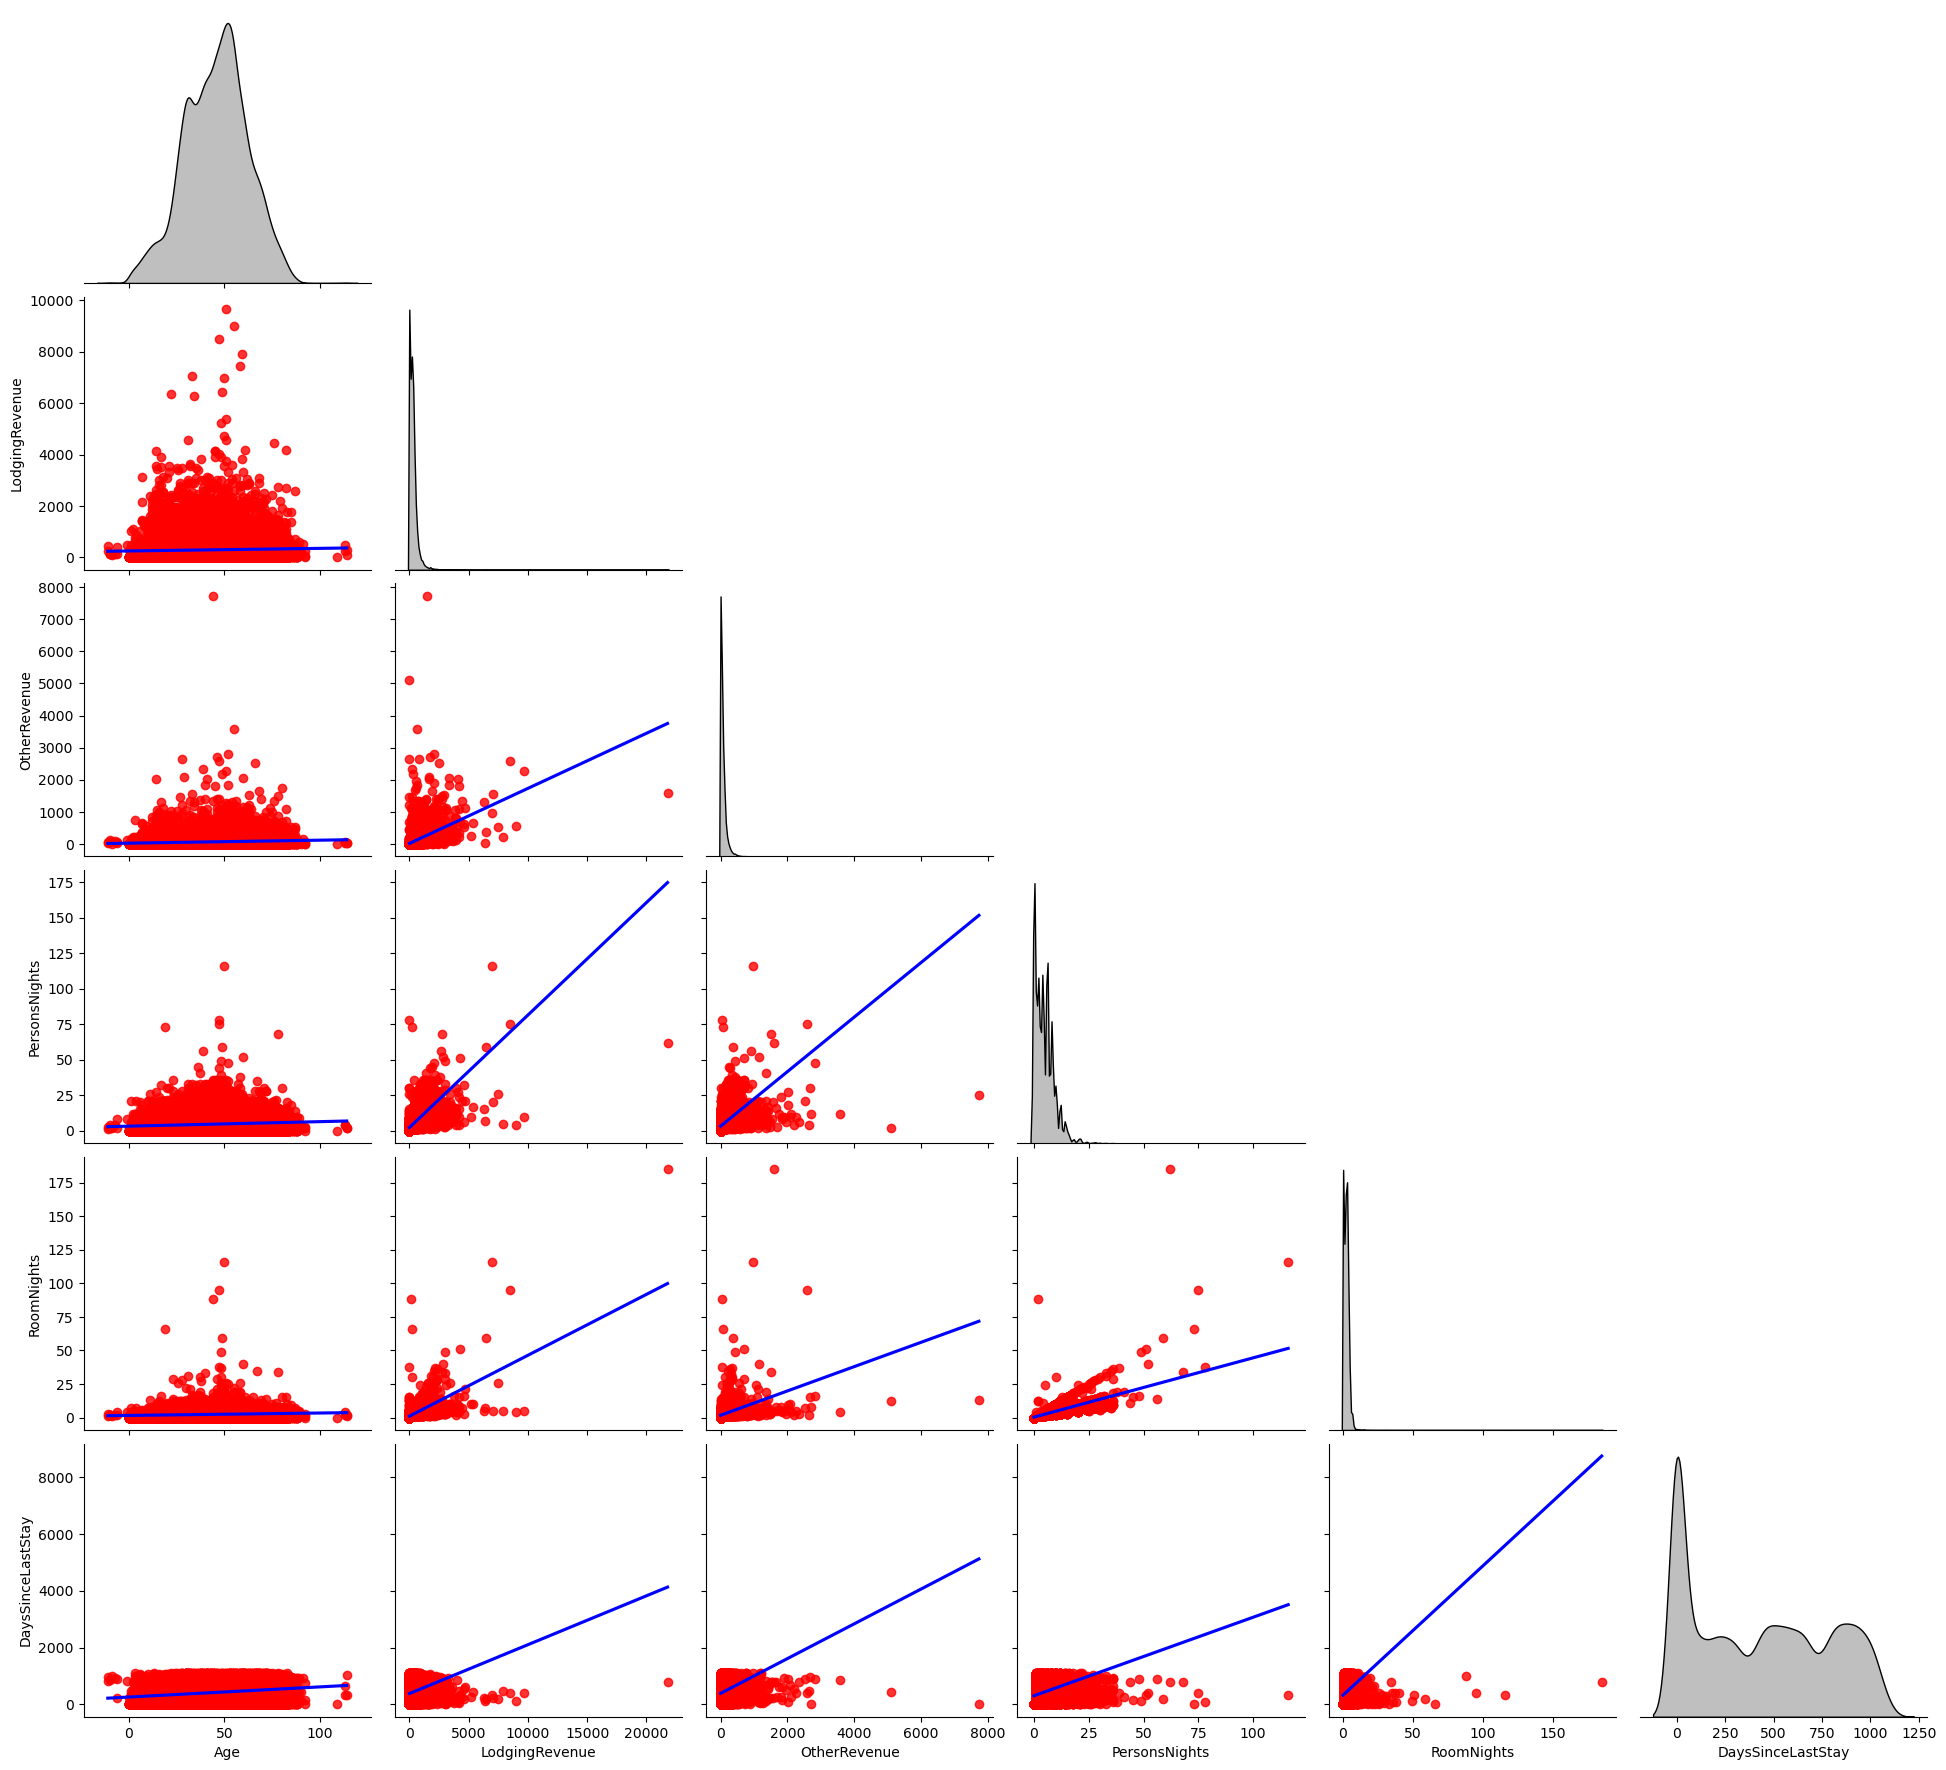

In [12]:
sns.pairplot(
	data=hotels.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR']"),
	kind="reg",
	diag_kind="kde",
	vars=("Age", "LodgingRevenue", "OtherRevenue", "PersonsNights", "RoomNights", "DaysSinceLastStay"),

	height=3,
	aspect=1.1,

	dropna=True,
	corner=True,

	plot_kws={"scatter_kws":{"color":"r"}, "line_kws": {"color":"b"}, "ci":None},
	diag_kws={"color":"0.0"}
);

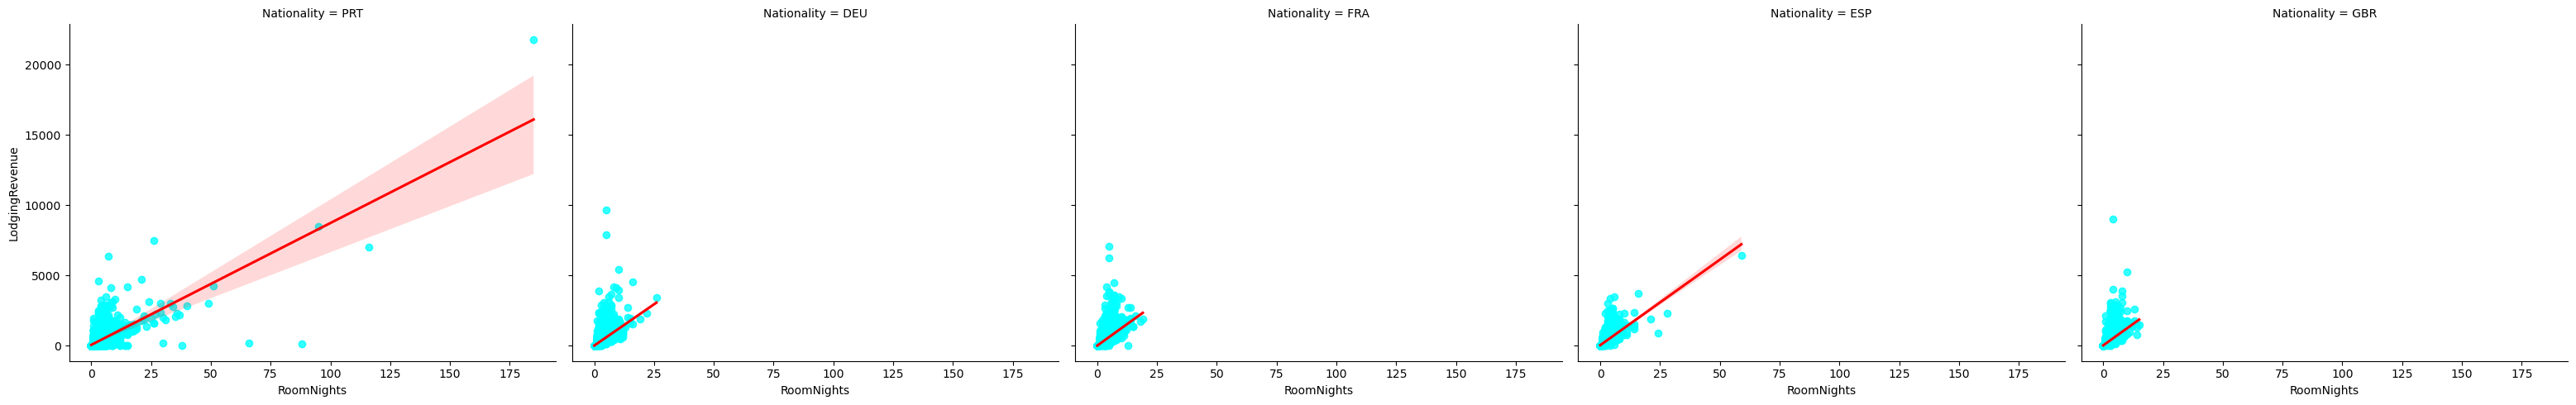

In [13]:
sns.lmplot(
    x="RoomNights",
    y="LodgingRevenue",
	data=hotels.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR']"),
	# order=2,
	# robust=True,
	# truncate=True,
	y_jitter=True,
	ci=95,
	line_kws={"color":"r"},
	scatter_kws={"color":"cyan"},
    col="Nationality",
	aspect=1.25   
);

# Assignment 4 Heatmaps


* Using the top 5 countries DataFrame, Build a heatmap of Nationality as rows and MarketSegment as columns with the mean value of LodgingRevenue in each cell.

* Then, build a heatmap of the correlation matrix created when using the .corr() method on the hotels dataframe. Use the 'vlag' color palette.

In [14]:
hotels_pivot = (hotels
	.pivot_table(index="Nationality", values="LodgingRevenue", columns="MarketSegment", aggfunc="mean")
	.query("Nationality in ['PRT', 'DEU', 'FRA', 'ESP', 'GBR']"))
hotels_pivot

MarketSegment,Aviation,Complementary,Corporate,Direct,Groups,Other,Travel Agent/Operator
Nationality,,,,,,,
DEU,586.100000,165.351111,286.381395,355.189467,293.921035,328.679177,234.815500
ESP,788.928571,0.000000,232.862384,321.377968,271.461086,314.819727,244.863591
FRA,637.000000,53.333333,280.838657,340.649577,230.373362,349.950256,202.730359
GBR,287.140000,84.150000,467.905287,351.774260,363.530552,309.845596,239.733048
PRT,434.535870,14.192343,276.862710,229.922979,234.751932,244.704767,233.157763


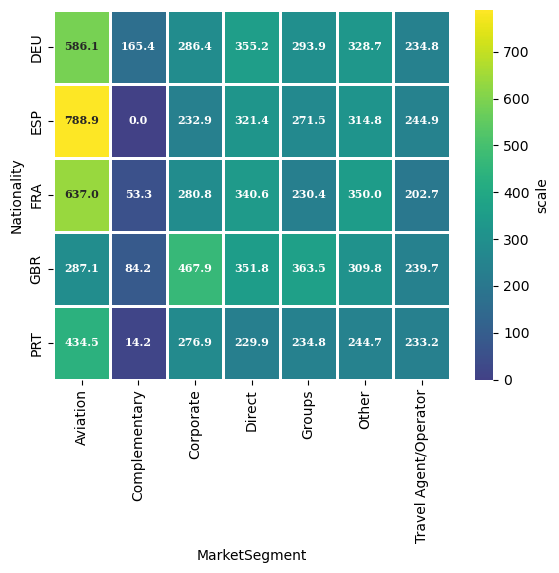

In [15]:
sns.heatmap(
	data=hotels_pivot,
	center=300,
	square=False,

	ec="white",
	lw=2,
	cmap="viridis",
	shading="flat",
	snap=True,
	norm="linear",
	
	annot=True,
	fmt=".1f",
	annot_kws={"family":"serif", "weight":"bold", "fontsize":8},

	cbar=True,
	cbar_kws={"fraction":0.15, "pad":0.05, "orientation":"vertical", "label":"scale"},
);

In [16]:
hotels_corr = hotels.iloc[:, :10].corr(numeric_only=True)

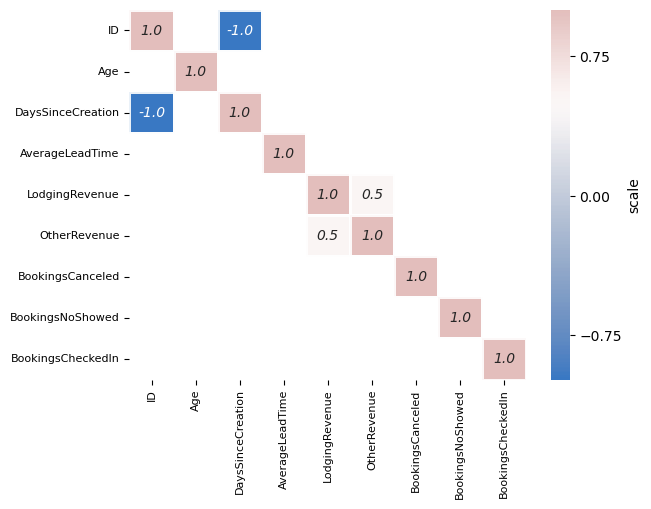

In [17]:
sns.heatmap(
	data=hotels_corr,
	mask=(hotels_corr > -0.5) & (hotels_corr < 0.5),

	center=0.5,
	square=False,

	annot=True,
	fmt=".1f",
	annot_kws={"style":"italic", "family":"sans serif"},

	cbar=True,
	cbar_kws={"label":"scale", 
			  "ticks":(-0.75, 0, 0.75)
			 },
	
	cmap="vlag",
	shading="flat",
	ec="0.5",
	lw=1,
	snap=True,
	norm="linear",
	alpha=0.9,
)
plt.tick_params(labelsize=8);